# Exploratory Data Analysis (EDA) & Data Cleaning

## Titanic Dataset — Week 1, Task 3

**Objective:** Perform data cleaning and Exploratory Data Analysis (EDA) on the Titanic dataset using Python, Pandas, Matplotlib, and Seaborn.

### Tasks covered
- Load and inspect the dataset
- Analyze missing values
- Detect and remove duplicate rows
- Correct data types
- Detect and handle outliers using the IQR method
- Visualize distributions and relationships
- Perform correlation analysis
- Document the top three correlation observations
- Export the cleaned dataset

## 1. Import Required Libraries

We use:
- **Pandas** for data loading, cleaning, and analysis
- **NumPy** for numerical operations
- **Matplotlib** for visualization
- **Seaborn** for statistical visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

The raw Titanic CSV file is loaded using Pandas. Keep `Titanic-Dataset.csv` in the same folder as this notebook.

In [2]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 12)


## 3. Initial Dataset Inspection

We inspect the first and last rows, dimensions, column names, data types, and summary statistics before performing any cleaning.

In [3]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Last 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q



Dataset shape:
(891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print("Data types:")
display(df.dtypes)

print("\nStatistical summary:")
display(df.describe())

Data types:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Statistical summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Missing Value Analysis

Missing values are checked column by column. We calculate both the number and percentage of missing values to decide the appropriate cleaning method.

In [6]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)

,Missing Values,Missing Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


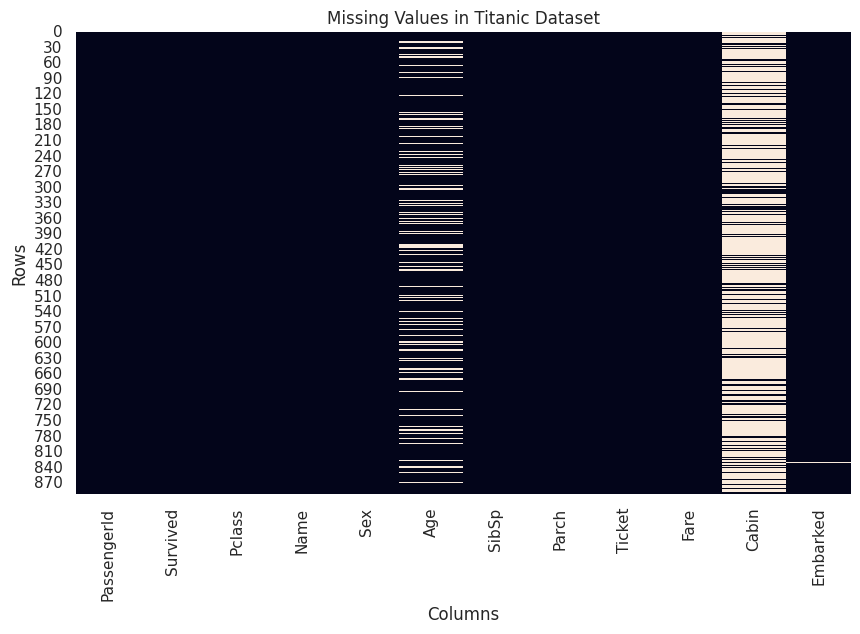

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

### Missing Value Treatment

- **Age:** numerical variable, so missing values are replaced with the median.
- **Embarked:** categorical variable, so missing values are replaced with the mode.
- **Cabin:** contains a large proportion of missing values. Instead of inventing cabin numbers, we create `Cabin_Known` to preserve whether cabin information was available, then remove the original `Cabin` column.

In [8]:
# Age: fill missing values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: fill missing values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: preserve availability information before removing the sparse column
df["Cabin_Known"] = df["Cabin"].notna().astype(int)
df.drop(columns=["Cabin"], inplace=True)

print("Missing-value treatment completed.")

Missing-value treatment completed.


## 5. Duplicate Row Analysis

Duplicate records can distort statistical analysis. We identify duplicate rows and remove them.

In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows before removal:", duplicate_count)

df.drop_duplicates(inplace=True)

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 0
Duplicate rows after removal: 0


## 6. Data Type Correction

`Survived` and `Pclass` represent categories. They are converted to categorical data types.

In [10]:
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")

display(df.dtypes)

,0
PassengerId,int64
Survived,category
Pclass,category
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## 7. Verify the Cleaned Data

We check whether any missing values or duplicate rows remain after the initial cleaning steps.

In [11]:
print("Missing values after cleaning:")
display(df.isnull().sum())

print("Total duplicate rows after cleaning:", df.duplicated().sum())

Missing values after cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Total duplicate rows after cleaning: 0


## 8. Exploratory Data Analysis

EDA helps us understand distributions and relationships in the dataset. We use count plots, histograms, box plots, and scatter plots.

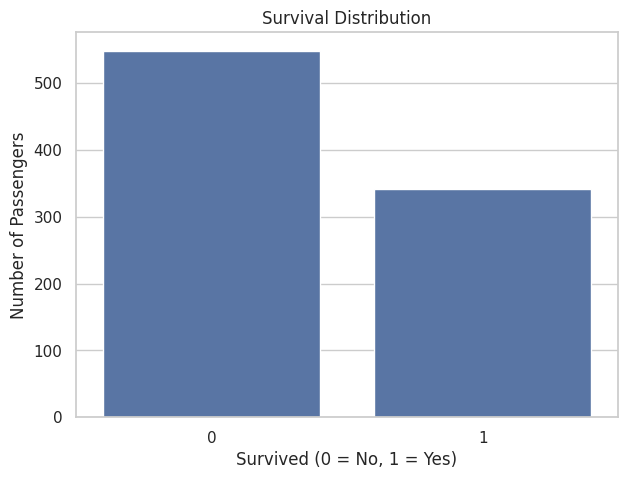

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

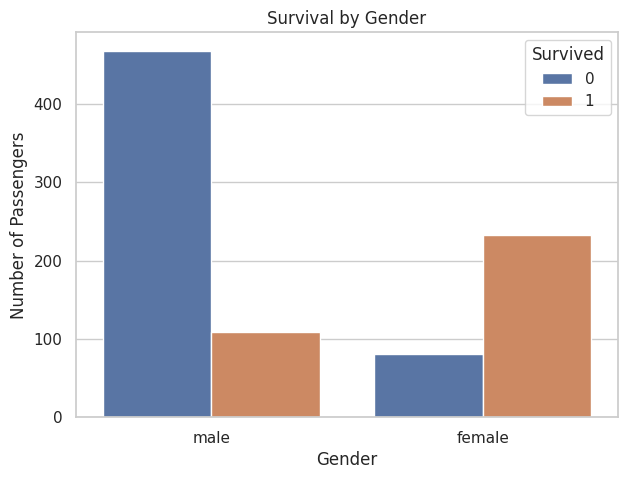

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

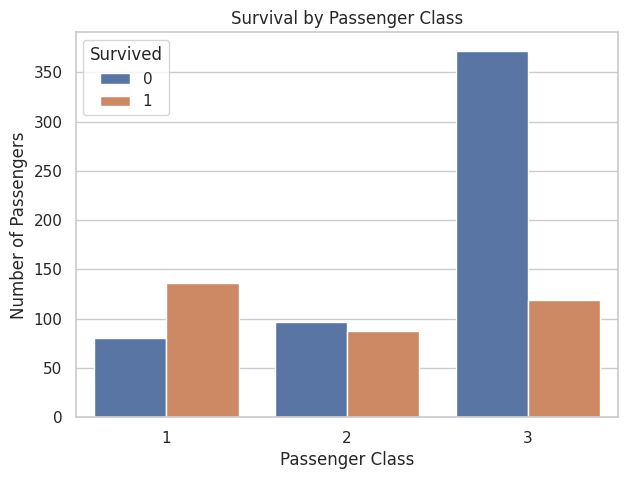

In [14]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

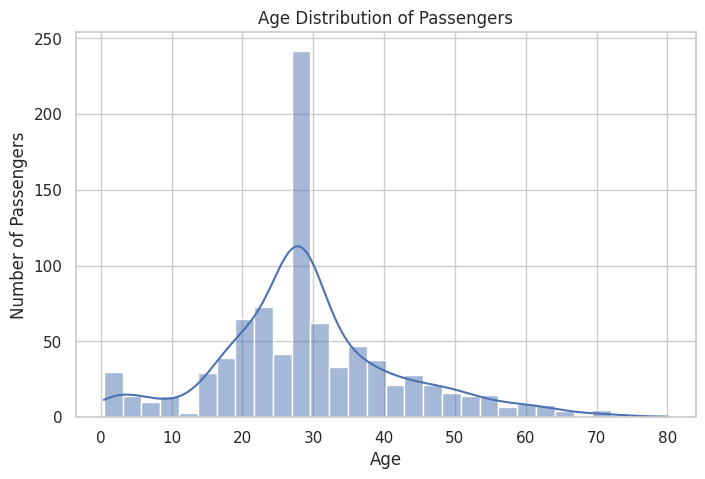

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

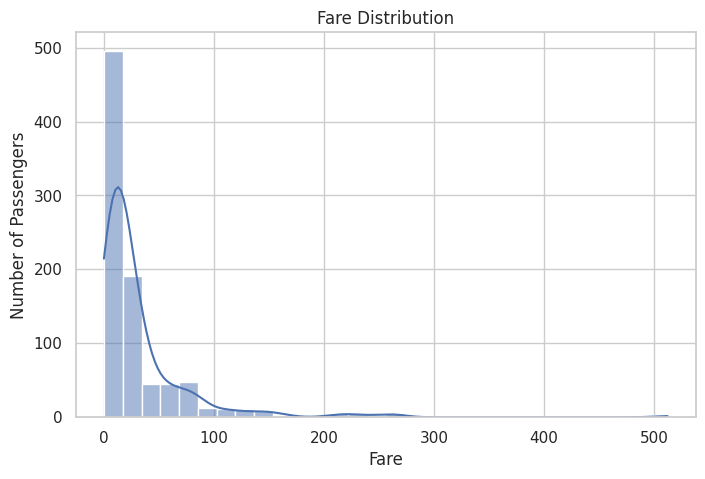

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

## 9. Outlier Detection

Box plots are used to visually identify potential outliers in numerical variables such as `Age` and `Fare`.

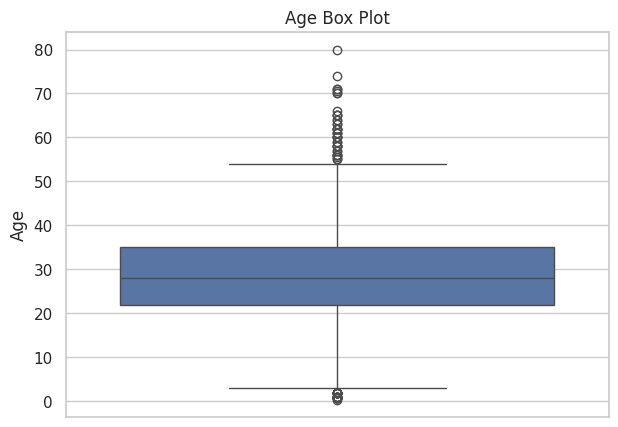

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, y="Age")
plt.title("Age Box Plot")
plt.ylabel("Age")
plt.show()

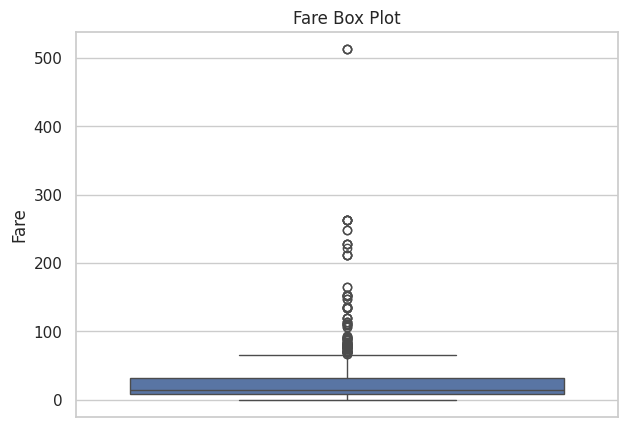

In [18]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, y="Fare")
plt.title("Fare Box Plot")
plt.ylabel("Fare")
plt.show()

## 10. IQR Outlier Detection

The Interquartile Range (IQR) method identifies observations outside:

- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

The function below calculates these limits and returns the detected outliers.

In [19]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, outliers

In [20]:
Q1_age, Q3_age, IQR_age, lower_age, upper_age, age_outliers = detect_outliers_iqr(df, "Age")

print("AGE OUTLIER ANALYSIS")
print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)
print("Lower Bound:", lower_age)
print("Upper Bound:", upper_age)
print("Number of Outliers:", len(age_outliers))

AGE OUTLIER ANALYSIS
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 66


In [21]:
Q1_fare, Q3_fare, IQR_fare, lower_fare, upper_fare, fare_outliers = detect_outliers_iqr(df, "Fare")

print("FARE OUTLIER ANALYSIS")
print("Q1:", Q1_fare)
print("Q3:", Q3_fare)
print("IQR:", IQR_fare)
print("Lower Bound:", lower_fare)
print("Upper Bound:", upper_fare)
print("Number of Outliers:", len(fare_outliers))

FARE OUTLIER ANALYSIS
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Outliers: 116


### Outlier Treatment

Very high fares can represent genuine first-class ticket prices rather than data-entry errors. Instead of deleting those records, we cap `Fare` at the IQR upper bound so that extreme values have less influence while observations are retained.

In [22]:
df["Fare"] = df["Fare"].clip(lower=lower_fare, upper=upper_fare)

print("Fare outliers capped using the IQR method.")

Fare outliers capped using the IQR method.


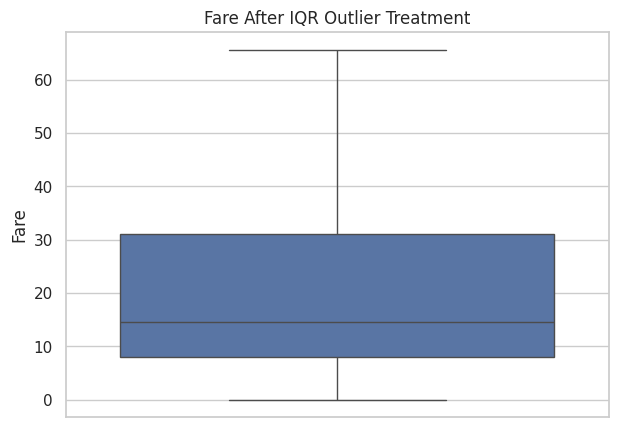

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, y="Fare")
plt.title("Fare After IQR Outlier Treatment")
plt.ylabel("Fare")
plt.show()

## 11. Additional EDA

We calculate survival rates by gender and passenger class and visualize survival by embarkation port.

In [27]:
df["Survived"] = pd.to_numeric(df["Survived"])
survival_by_gender = df.groupby("Sex", observed=True)["Survived"].mean()
print("Survival rate by gender:")
display(survival_by_gender)

Survival rate by gender:


,Survived
Sex,
female,0.742038
male,0.188908


In [28]:
survival_by_class = df.groupby("Pclass", observed=True)["Survived"].mean()
print("Survival rate by passenger class:")
display(survival_by_class)

Survival rate by passenger class:


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


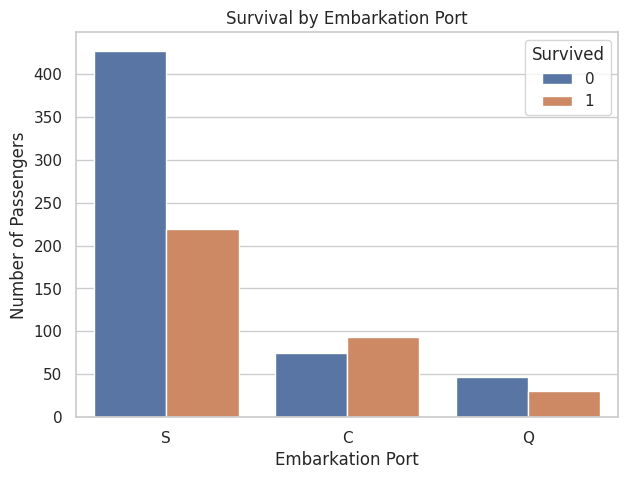

In [29]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Embarked", hue="Survived")
plt.title("Survival by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")
plt.show()

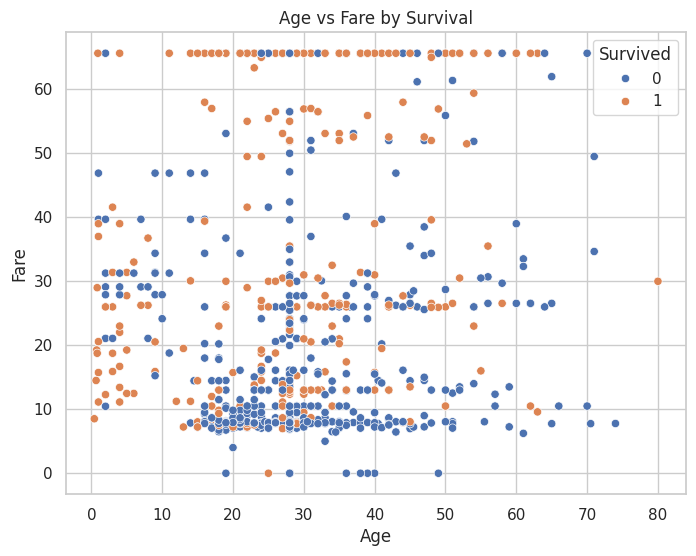

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived")
plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## 12. Correlation Analysis

Correlation measures the strength and direction of linear relationships between numerical variables.

- A value close to **+1** indicates a strong positive relationship.
- A value close to **0** indicates a weak or no linear relationship.
- A value close to **−1** indicates a strong negative relationship.

In [31]:
numerical_df = df.select_dtypes(include=["number"])

correlation_matrix = numerical_df.corr()

display(correlation_matrix)

,PassengerId,Survived,Age,SibSp,Parch,Fare,Cabin_Known
PassengerId,1.000000,-0.005007,0.034212,-0.057527,-0.001652,0.003243,0.019919
Survived,-0.005007,1.000000,-0.064910,-0.035322,0.081629,0.317430,0.316912
Age,0.034212,-0.064910,1.000000,-0.233296,-0.172482,0.144204,0.240314
SibSp,-0.057527,-0.035322,-0.233296,1.000000,0.414838,0.332021,-0.040460
Parch,-0.001652,0.081629,-0.172482,0.414838,1.000000,0.292616,0.036987
Fare,0.003243,0.317430,0.144204,0.332021,0.292616,1.000000,0.617669
Cabin_Known,0.019919,0.316912,0.240314,-0.040460,0.036987,0.617669,1.000000


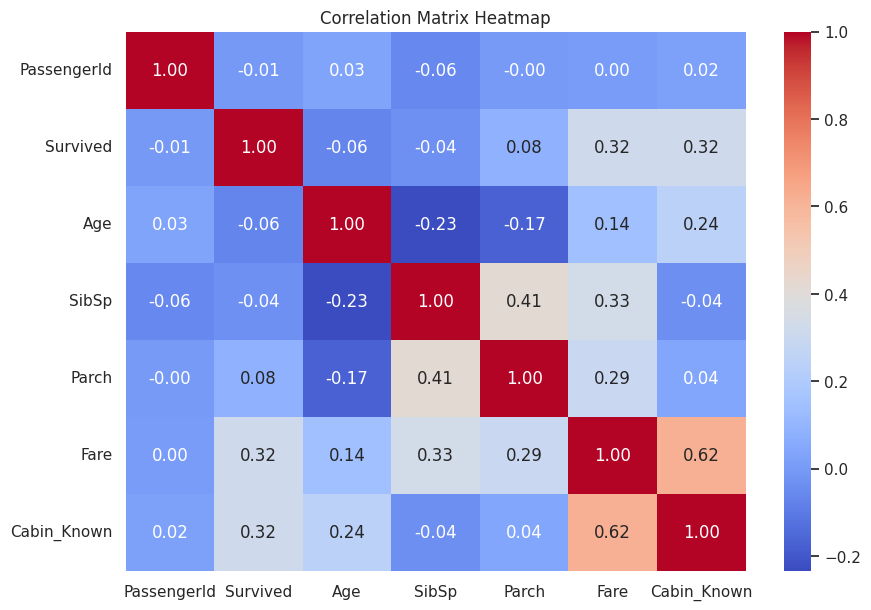

In [32]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix Heatmap")
plt.show()

## 13. Top Three Correlation Observations

1. **Fare and Pclass:** Passenger class and fare are related. Higher-class passengers generally paid higher fares.

2. **Survived and Fare:** Fare has a positive relationship with survival, meaning passengers with higher fares generally had better survival outcomes.

3. **Survived and Pclass:** Passenger class is associated with survival. Higher-class passengers generally had higher survival rates than lower-class passengers.

> Correlation indicates association, not causation.

## 14. Final Data Quality Check

The final dataset is checked for missing values, duplicate rows, and its final dimensions.

In [33]:
print("Final dataset shape:", df.shape)

print("\nFinal missing values:")
display(df.isnull().sum())

print("\nFinal duplicate count:")
print(df.duplicated().sum())

print("\nFinal first five rows:")
display(df.head())

Final dataset shape: (891, 12)

Final missing values:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



Final duplicate count:
0

Final first five rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_Known
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


## 15. Export the Cleaned Dataset

The cleaned dataset is saved as a new CSV file. The original raw dataset remains unchanged.

In [34]:
output_file = "cleaned_Titanic_Dataset.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned dataset saved as: {output_file}")

Cleaned dataset saved as: cleaned_Titanic_Dataset.csv


# Conclusion

The Titanic dataset was successfully cleaned and explored.

### Cleaning performed
- Identified missing values and calculated their percentages.
- Filled missing `Age` values using the median.
- Filled missing `Embarked` values using the mode.
- Created `Cabin_Known` to preserve cabin availability information.
- Removed the original `Cabin` column because of extensive missing data.
- Detected and removed duplicate rows.
- Converted appropriate variables to categorical data types.
- Detected `Age` and `Fare` outliers using the IQR method.
- Capped extreme `Fare` values using the IQR upper bound.

### EDA performed
- Survival distribution
- Survival by gender
- Survival by passenger class
- Age distribution
- Fare distribution
- Outlier visualization
- Survival by embarkation port
- Age vs Fare analysis
- Correlation matrix and heatmap

The cleaned dataset was exported as `cleaned_Titanic_Dataset.csv`.